# Experimentos 4 y 5: Visual + Metadata limpia
**Experimento 4:** CLIP (imagen) + metadata limpia  
**Experimento 5:** DINOv2 (imagen) + metadata limpia  
**Dataset:** PAD-UFES-20 — clasificación binaria (maligno vs benigno)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Dispositivo: cuda
GPU: Tesla T4


## 1. Rutas y carga de embeddings visuales

In [3]:
BASE_PATH    = '/content/drive/MyDrive/PFC1 - Noemi/dataset/PAD-UFES-20'
RESULTS_PATH = os.path.join(BASE_PATH, 'resultados')

# Embeddings visuales ya guardados
clip_train = np.load(os.path.join(RESULTS_PATH, 'clip_X_train.npy'))
clip_val   = np.load(os.path.join(RESULTS_PATH, 'clip_X_val.npy'))
clip_test  = np.load(os.path.join(RESULTS_PATH, 'clip_X_test.npy'))

dino_train = np.load(os.path.join(RESULTS_PATH, 'dino_X_train.npy'))
dino_val   = np.load(os.path.join(RESULTS_PATH, 'dino_X_val.npy'))
dino_test  = np.load(os.path.join(RESULTS_PATH, 'dino_X_test.npy'))

y_train = np.load(os.path.join(RESULTS_PATH, 'y_train.npy'))
y_val   = np.load(os.path.join(RESULTS_PATH, 'y_val.npy'))
y_test  = np.load(os.path.join(RESULTS_PATH, 'y_test.npy'))

print(f'CLIP  — train: {clip_train.shape}')
print(f'DINOv2 — train: {dino_train.shape}')
print(f'Labels — train: {y_train.shape}')

CLIP  — train: (1838, 768)
DINOv2 — train: (1838, 1024)
Labels — train: (1838,)


## 2. Preprocesamiento de metadata clínica
Igual que describe la tesis (Sección III.B.3):  
- Variables categóricas → one-hot encoding  
- Variables continuas → Min-Max scaling

In [4]:
# Cargar splits con metadata
df_train = pd.read_csv(os.path.join(BASE_PATH, 'split_train.csv'))
df_val   = pd.read_csv(os.path.join(BASE_PATH, 'split_val.csv'))
df_test  = pd.read_csv(os.path.join(BASE_PATH, 'split_test.csv'))

# Columnas clínicas a usar (excluir identificadores y label)
META_COLS = [
    'smoke', 'drink', 'pesticide', 'gender',
    'skin_cancer_history', 'cancer_history',
    'has_piped_water', 'has_sewage_system',
    'age', 'fitspatrick', 'diameter_1', 'diameter_2',
    'region', 'background_father', 'background_mother',
    'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation'
]

# Columnas numéricas continuas → Min-Max
NUM_COLS = ['age', 'fitspatrick', 'diameter_1', 'diameter_2']

# Columnas categóricas → one-hot
CAT_COLS = [c for c in META_COLS if c not in NUM_COLS]

print(f'Columnas numéricas ({len(NUM_COLS)}): {NUM_COLS}')
print(f'Columnas categóricas ({len(CAT_COLS)}): {CAT_COLS}')

Columnas numéricas (4): ['age', 'fitspatrick', 'diameter_1', 'diameter_2']
Columnas categóricas (17): ['smoke', 'drink', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'region', 'background_father', 'background_mother', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation']


In [5]:
def preprocess_metadata(df_train, df_val, df_test, meta_cols, num_cols, cat_cols):
    """
    Preprocesa metadata clínica:
    - Numéricas: Min-Max scaling (fit solo en train)
    - Categóricas: one-hot encoding (fit solo en train)
    """
    # Extraer columnas relevantes
    tr = df_train[meta_cols].copy()
    va = df_val[meta_cols].copy()
    te = df_test[meta_cols].copy()

    # Min-Max en numéricas — fit solo en train
    scaler = MinMaxScaler()
    tr[num_cols] = scaler.fit_transform(tr[num_cols])
    va[num_cols] = scaler.transform(va[num_cols])
    te[num_cols] = scaler.transform(te[num_cols])

    # Convertir booleanos a int
    for df in [tr, va, te]:
        for col in df.select_dtypes(include='bool').columns:
            df[col] = df[col].astype(int)

    # One-hot en categóricas — fit solo en train
    string_cats = [c for c in cat_cols if tr[c].dtype == object]
    tr_enc = pd.get_dummies(tr, columns=string_cats)
    va_enc = pd.get_dummies(va, columns=string_cats)
    te_enc = pd.get_dummies(te, columns=string_cats)

    # Alinear columnas (val/test pueden tener menos categorías)
    va_enc = va_enc.reindex(columns=tr_enc.columns, fill_value=0)
    te_enc = te_enc.reindex(columns=tr_enc.columns, fill_value=0)

    return tr_enc.values.astype(np.float32), va_enc.values.astype(np.float32), te_enc.values.astype(np.float32)

M_train, M_val, M_test = preprocess_metadata(
    df_train, df_val, df_test, META_COLS, NUM_COLS, CAT_COLS
)

print(f'Metadata procesada — train: {M_train.shape} | val: {M_val.shape} | test: {M_test.shape}')

Metadata procesada — train: (1838, 69) | val: (230, 69) | test: (230, 69)


## 3. Función de entrenamiento y evaluación (reutilizable)

In [7]:
def run_experiment(X_train, X_val, X_test, y_train, y_val, y_test,
                   nombre, hidden=512, epochs=30, lr=1e-3, patience=10):
    """
    Entrena cabeza lineal sobre embeddings fusionados y evalúa en test.
    Retorna diccionario con métricas.
    """
    input_dim = X_train.shape[1]

    # DataLoaders
    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
        batch_size=64, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
        batch_size=64, shuffle=False
    )
    test_loader = DataLoader(
        TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
        batch_size=64, shuffle=False
    )

    # Modelo
    head = nn.Sequential(
        nn.Linear(input_dim, hidden),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(hidden, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 1)
    ).to(device)

    criterion      = nn.BCEWithLogitsLoss()
    optimizer      = torch.optim.Adam(head.parameters(), lr=lr, weight_decay=1e-4)
    scheduler      = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    best_auc       = 0
    pat_count      = 0
    best_path      = os.path.join(RESULTS_PATH, f'{nombre}_head.pt')
    history        = {'train_loss': [], 'val_loss': [], 'val_auc': []}

    print(f'\n{'='*50}')
    print(f'  {nombre} — input dim: {input_dim}')
    print(f'{'='*50}')

    for epoch in range(epochs):
        head.train()
        train_loss = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(head(X_b).squeeze(1), y_b)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        head.eval()
        val_loss, vprobs, vlabels = 0, [], []
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                out       = head(X_b).squeeze(1)
                val_loss += criterion(out, y_b).item()
                vprobs.extend(torch.sigmoid(out).cpu().numpy())
                vlabels.extend(y_b.cpu().numpy())
        val_loss /= len(val_loader)
        val_auc   = roc_auc_score(vlabels, vprobs)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)

        print(f'Epoch {epoch+1:02d} | Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}')

        if val_auc > best_auc:
            best_auc  = val_auc
            torch.save(head.state_dict(), best_path)
            pat_count = 0
            print(f' Mejor modelo (AUC={best_auc:.4f})')
        else:
            pat_count += 1
            if pat_count >= patience:
                print(f' Early stopping epoch {epoch+1}')
                break

    # Evaluación en test
    head.load_state_dict(torch.load(best_path))
    head.eval()
    tprobs, tlabels = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            out = head(X_b.to(device)).squeeze(1)
            tprobs.extend(torch.sigmoid(out).cpu().numpy())
            tlabels.extend(y_b.numpy())

    tprobs  = np.array(tprobs)
    tlabels = np.array(tlabels)
    tpreds  = (tprobs >= 0.5).astype(int)

    auc  = roc_auc_score(tlabels, tprobs)
    acc  = accuracy_score(tlabels, tpreds)
    pre  = precision_score(tlabels, tpreds)
    rec  = recall_score(tlabels, tpreds)
    f1   = f1_score(tlabels, tpreds)

    print(f'\nRESULTADOS FINALES — {nombre}')
    print(f'  AUC: {auc:.4f} | Acc: {acc*100:.1f}% | Pre: {pre*100:.1f}% | Rec: {rec*100:.1f}% | F1: {f1:.4f}')
    print(classification_report(tlabels, tpreds, target_names=['Benigno', 'Maligno']))

    # Matriz de confusión
    cm = confusion_matrix(tlabels, tpreds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benigno','Maligno'],
                yticklabels=['Benigno','Maligno'], ax=ax)
    ax.set_title(f'Confusión — {nombre}', fontweight='bold')
    ax.set_ylabel('Real'); ax.set_xlabel('Predicho')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, f'{nombre}_confusion.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Curvas
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history['train_loss'], label='Train', color='#3498db')
    axes[0].plot(history['val_loss'],   label='Val',   color='#e74c3c')
    axes[0].set_title('Loss'); axes[0].legend()
    axes[1].plot(history['val_auc'], color='#2ecc71')
    axes[1].set_title('Val AUC-ROC')
    plt.suptitle(f'{nombre} — Curvas', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH, f'{nombre}_curvas.png'), dpi=150, bbox_inches='tight')
    plt.show()

    return {'modelo': nombre, 'auc': round(auc,4), 'accuracy': round(acc,4),
            'precision': round(pre,4), 'recall': round(rec,4), 'f1': round(f1,4)}

print('Función lista')

Función lista


## 4. Experimento 4 — CLIP + metadata limpia

Dimensión: 768 (CLIP) + 69 (metadata) = 837

  clip_metadata — input dim: 837
Epoch 01 | Loss: 0.4339 | Val Loss: 0.2915 | Val AUC: 0.9523
 Mejor modelo (AUC=0.9523)
Epoch 02 | Loss: 0.2704 | Val Loss: 0.2672 | Val AUC: 0.9638
 Mejor modelo (AUC=0.9638)
Epoch 03 | Loss: 0.2408 | Val Loss: 0.2503 | Val AUC: 0.9656
 Mejor modelo (AUC=0.9656)
Epoch 04 | Loss: 0.2113 | Val Loss: 0.2482 | Val AUC: 0.9669
 Mejor modelo (AUC=0.9669)
Epoch 05 | Loss: 0.1964 | Val Loss: 0.2402 | Val AUC: 0.9680
 Mejor modelo (AUC=0.9680)
Epoch 06 | Loss: 0.1760 | Val Loss: 0.2328 | Val AUC: 0.9666
Epoch 07 | Loss: 0.1764 | Val Loss: 0.2513 | Val AUC: 0.9675
Epoch 08 | Loss: 0.1613 | Val Loss: 0.2449 | Val AUC: 0.9698
 Mejor modelo (AUC=0.9698)
Epoch 09 | Loss: 0.1295 | Val Loss: 0.2337 | Val AUC: 0.9666
Epoch 10 | Loss: 0.1183 | Val Loss: 0.2298 | Val AUC: 0.9662
Epoch 11 | Loss: 0.1056 | Val Loss: 0.2366 | Val AUC: 0.9674
Epoch 12 | Loss: 0.1009 | Val Loss: 0.2482 | Val AUC: 0.9671
Epoch 13 | Loss: 0.0952 | Va

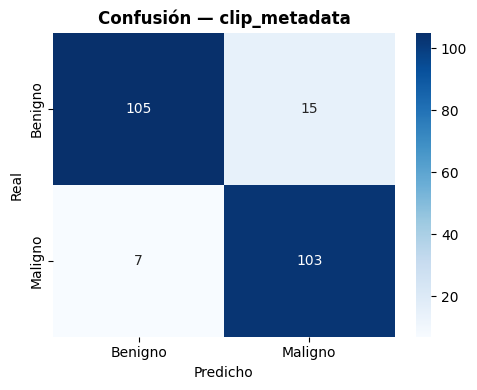

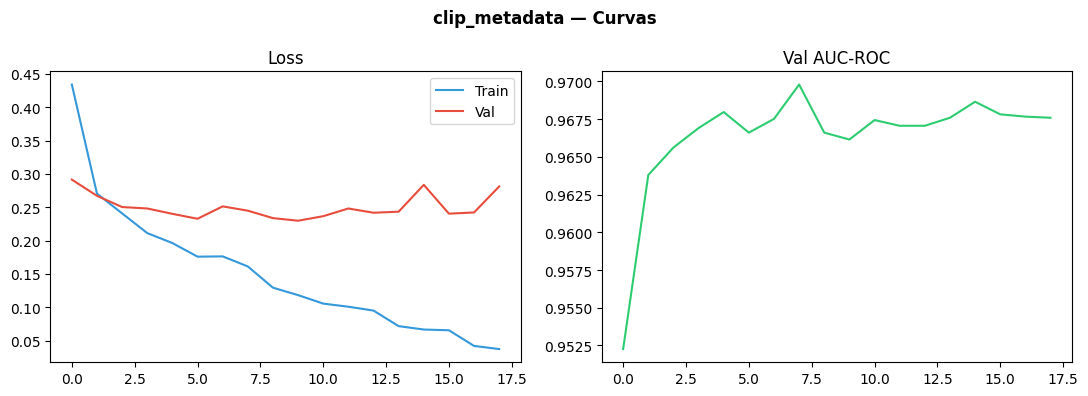

Guardado


In [8]:
# Fusionar: CLIP (768) + metadata
X_tr_clip_meta = np.concatenate([clip_train, M_train], axis=1)
X_v_clip_meta  = np.concatenate([clip_val,   M_val],   axis=1)
X_te_clip_meta = np.concatenate([clip_test,  M_test],  axis=1)

print(f'Dimensión: 768 (CLIP) + {M_train.shape[1]} (metadata) = {X_tr_clip_meta.shape[1]}')

results_clip_meta = run_experiment(
    X_tr_clip_meta, X_v_clip_meta, X_te_clip_meta,
    y_train, y_val, y_test,
    nombre='clip_metadata'
)

pd.DataFrame([results_clip_meta]).to_csv(
    os.path.join(RESULTS_PATH, 'resultados_clip_metadata.csv'), index=False
)
print('Guardado')

## 5. Experimento 5 — DINOv2 + metadata limpia

Dimensión: 1024 (DINOv2) + 69 (metadata) = 1093

  dino_metadata — input dim: 1093
Epoch 01 | Loss: 0.4388 | Val Loss: 0.2806 | Val AUC: 0.9589
 Mejor modelo (AUC=0.9589)
Epoch 02 | Loss: 0.2751 | Val Loss: 0.2565 | Val AUC: 0.9684
 Mejor modelo (AUC=0.9684)
Epoch 03 | Loss: 0.2391 | Val Loss: 0.2467 | Val AUC: 0.9709
 Mejor modelo (AUC=0.9709)
Epoch 04 | Loss: 0.2216 | Val Loss: 0.2305 | Val AUC: 0.9707
Epoch 05 | Loss: 0.2152 | Val Loss: 0.2394 | Val AUC: 0.9702
Epoch 06 | Loss: 0.2015 | Val Loss: 0.2209 | Val AUC: 0.9707
Epoch 07 | Loss: 0.1704 | Val Loss: 0.2186 | Val AUC: 0.9715
 Mejor modelo (AUC=0.9715)
Epoch 08 | Loss: 0.1614 | Val Loss: 0.2168 | Val AUC: 0.9721
 Mejor modelo (AUC=0.9721)
Epoch 09 | Loss: 0.1499 | Val Loss: 0.2332 | Val AUC: 0.9721
Epoch 10 | Loss: 0.1281 | Val Loss: 0.2173 | Val AUC: 0.9709
Epoch 11 | Loss: 0.1195 | Val Loss: 0.2049 | Val AUC: 0.9739
 Mejor modelo (AUC=0.9739)
Epoch 12 | Loss: 0.1161 | Val Loss: 0.2079 | Val AUC: 0.9741
 Mejor modelo (AUC=0.97

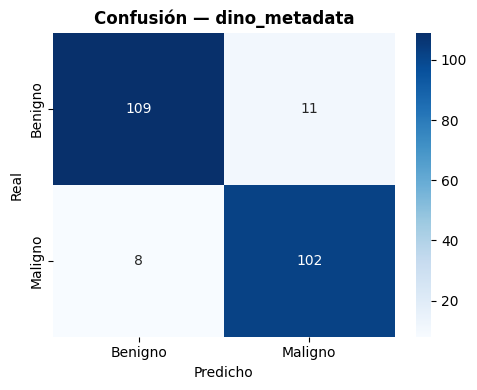

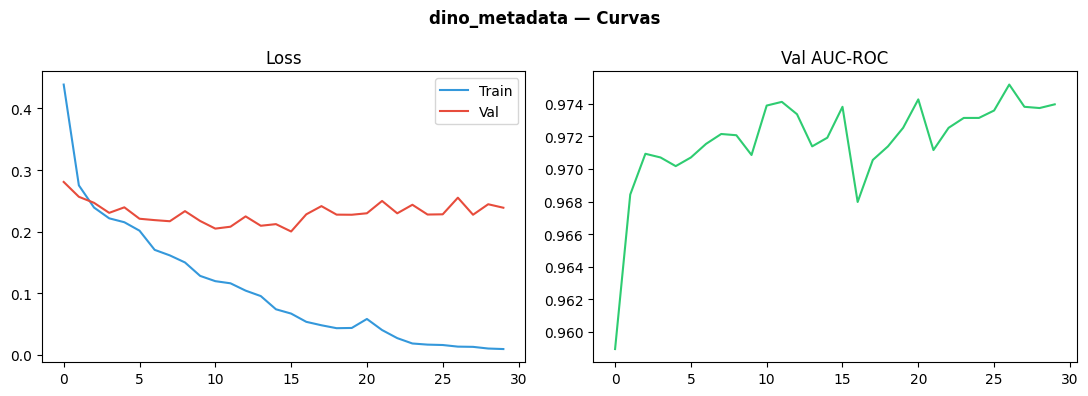

Guardado


In [9]:
# Fusionar: DINOv2 (1024) + metadata
X_tr_dino_meta = np.concatenate([dino_train, M_train], axis=1)
X_v_dino_meta  = np.concatenate([dino_val,   M_val],   axis=1)
X_te_dino_meta = np.concatenate([dino_test,  M_test],  axis=1)

print(f'Dimensión: 1024 (DINOv2) + {M_train.shape[1]} (metadata) = {X_tr_dino_meta.shape[1]}')

results_dino_meta = run_experiment(
    X_tr_dino_meta, X_v_dino_meta, X_te_dino_meta,
    y_train, y_val, y_test,
    nombre='dino_metadata'
)

pd.DataFrame([results_dino_meta]).to_csv(
    os.path.join(RESULTS_PATH, 'resultados_dino_metadata.csv'), index=False
)
print('Guardado')

## 6. Resumen comparativo

In [10]:
resumen = pd.DataFrame([results_clip_meta, results_dino_meta])
print('\n=== RESUMEN EXPERIMENTOS 4 y 5 ===')
print(resumen.to_string(index=False))


=== RESUMEN EXPERIMENTOS 4 y 5 ===
       modelo    auc  accuracy  precision  recall     f1
clip_metadata 0.9692    0.9043     0.8729  0.9364 0.9035
dino_metadata 0.9723    0.9174     0.9027  0.9273 0.9148
